# Acoustic Scan 

In [1]:
# matching pursuit
# depth profiling
# attenuation with high f. reflection ok, transmission no
# look at acoustic resonances, dip in attenuation
# 

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pyplot as plt
import sys


sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/M3Learning-Util/src')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/AutoPhysLearn/src')
sys.path.append('/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonic_ml/src')


from scipy.signal import butter, sosfiltfilt
import copy
import math
import time
from tqdm import tqdm
import pickleJar as pj
import tomography as tm

In [3]:
from viz.visualize_scan_data import *
from IPython.display import display
import plotly.graph_objects as go

## Dataloader with preprocessing

In [ ]:
from data import datasets
from data.datasets import morlet_1D_dataset_real

dset = morlet_1D_dataset_real(sq3lite_path='/Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.sqlite3',
                              # dset_name='voltage_transmission_forward',
                              dset_name='voltage_echo_forward',
                              image_shape = (1,1),
                            #   crops = [(0,4000)] #(15000,19000)
                            ) 

sqliteToPickle Warning: pickle file /Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.pickle already exists. Conversion aborted.
preprocessing data...


  0%|          | 0/1911 [00:00<?, ?it/s]/Users/xz498/Desktop/ultrasound project/data analysis/ultrasonicTesting/pickleJar.py:1185: RuntimeWarning: divide by zero encountered in log10
  logData = np.log10(abs(data))
100%|██████████| 1911/1911 [00:01<00:00, 1263.87it/s]


In [ ]:
dset.preprocess_data_additional(np.fft.fft, 'max', axis=1)

In [72]:
for k in dset.data.keys(): 
    if not isinstance(k, int): print(k)

fileName
parameters
processed_voltage_echo_forward
processed_voltage_echo_forward_max


In [73]:
dset.data['processed_voltage_echo_forward'].shape, dset.data['processed_voltage_echo_forward_max'].shape

((1911, 10000), (1911,))

### FFTs

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_8485/5020257.py:26: RuntimeWarning: divide by zero encountered in divide
  axs[3, 0].plot(freq[freq_crop[0]:freq_crop[1]], (-morlet_phase/freq)[freq_crop[0]:freq_crop[1]])
/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_8485/5020257.py:36: RuntimeWarning: divide by zero encountered in divide
  axs[3, 1].plot(freq[freq_crop[0]:freq_crop[1]], (-morlet_phase/freq)[freq_crop[0]:freq_crop[1]])
/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_8485/5020257.py:47: RuntimeWarning: divide by zero encountered in divide
  axs[3, 2].plot(freq[freq_crop[0]:freq_crop[1]], (-echo_phase/freq)[freq_crop[0]:freq_crop[1]])


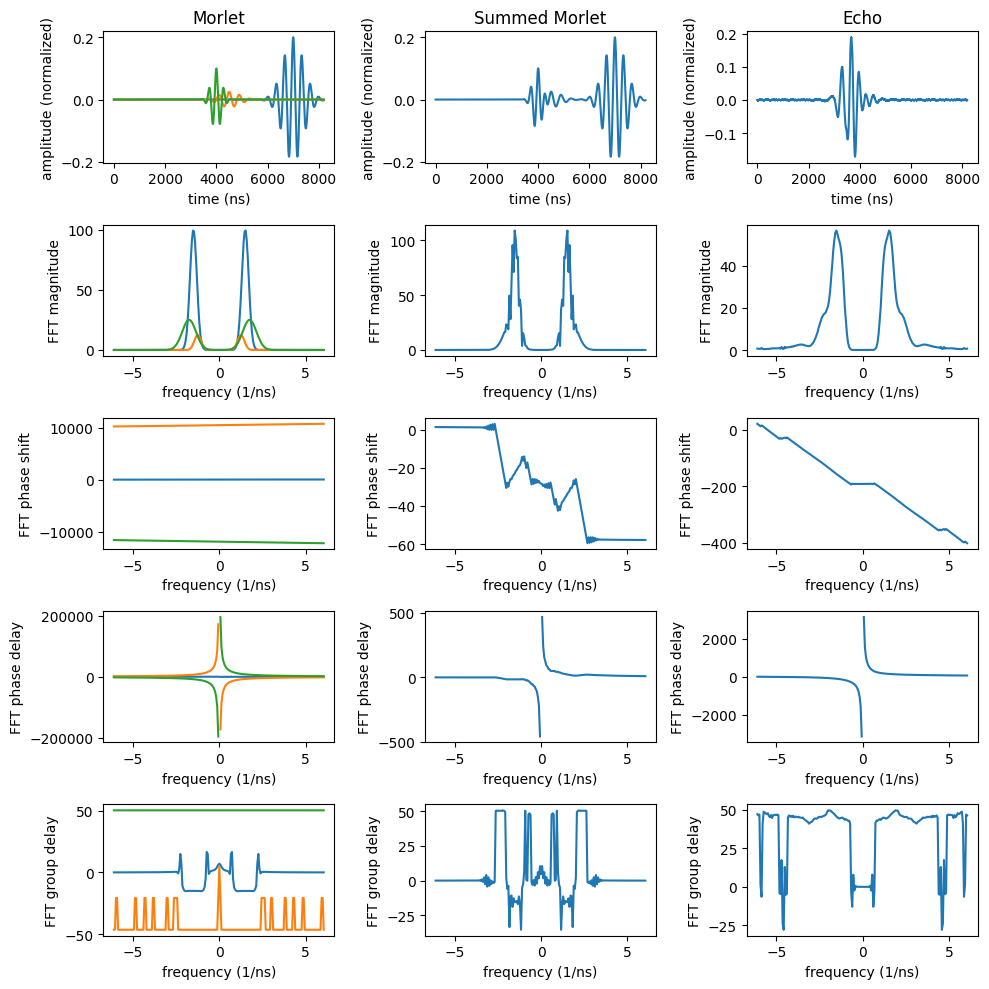

In [184]:
import numpy as np
import matplotlib.pyplot as plt
from models.morlet_fitter import morlet_1D_fitters_real
import torch

idx = 1034
data_crop = 2**13
freq_crop = [data_crop//2-100,data_crop//2+100]
sample_rate = float(1.0 / dset.dt)
fig, axs = plt.subplots(5, 3, figsize=(10, 10))
parameters = torch.tensor([[ [0.2, 7000, 400, 3.0e-03],
                            [0.025, 4500, 400, 2.5e-03],
                            [0.1, 4000, 200, 3.5e-03] ]])
fitter = morlet_1D_fitters_real(limits=[1, dset.spec_len, dset.spec_len / 5, 0.05])
t = np.linspace(0, data_crop, data_crop)
freq = np.fft.fftshift(np.fft.fftfreq(data_crop, dset.dt))

axs[0, 0].set_title("Morlet")
test_morlet = fitter.generate_fit(parameters, data_crop)
for i,morlet in enumerate(test_morlet[0]):
    fft_morlet = np.fft.fftshift(np.fft.fft(morlet))
    axs[0, 0].plot(t, morlet)
    axs[1, 0].plot(freq[freq_crop[0]:freq_crop[1]], np.abs(fft_morlet[freq_crop[0]:freq_crop[1]]))
    morlet_phase = np.unwrap(np.angle(fft_morlet))
    axs[2, 0].plot(freq[freq_crop[0]:freq_crop[1]], morlet_phase[freq_crop[0]:freq_crop[1]])
    axs[3, 0].plot(freq[freq_crop[0]:freq_crop[1]], (-morlet_phase/freq)[freq_crop[0]:freq_crop[1]])
    axs[4, 0].plot(freq[freq_crop[0]:freq_crop[1]], -np.gradient(morlet_phase, freq)[freq_crop[0]:freq_crop[1]])

axs[0, 1].set_title("Summed Morlet")
summed_morlet = test_morlet[0].sum(axis=0)    
axs[0, 1].plot(t, summed_morlet)
fft_summed_morlet = np.fft.fftshift(np.fft.fft(summed_morlet))
axs[1, 1].plot(freq[freq_crop[0]:freq_crop[1]], np.abs(fft_summed_morlet[freq_crop[0]:freq_crop[1]]))
morlet_phase = np.unwrap(np.angle(fft_summed_morlet))
axs[2, 1].plot(freq[freq_crop[0]:freq_crop[1]], morlet_phase[freq_crop[0]:freq_crop[1]])
axs[3, 1].plot(freq[freq_crop[0]:freq_crop[1]], (-morlet_phase/freq)[freq_crop[0]:freq_crop[1]])
axs[4, 1].plot(freq[freq_crop[0]:freq_crop[1]], -np.gradient(morlet_phase, freq)[freq_crop[0]:freq_crop[1]])


axs[0, 2].set_title("Echo")
echo = dset.data["processed_voltage_echo_forward"][idx][:data_crop]       
axs[0, 2].plot(t, echo)
fft_echo = np.fft.fftshift(np.fft.fft(echo))
axs[1, 2].plot(freq[freq_crop[0]:freq_crop[1]], np.abs(fft_echo[freq_crop[0]:freq_crop[1]]))
echo_phase = np.unwrap(np.angle(fft_echo))
axs[2, 2].plot(freq[freq_crop[0]:freq_crop[1]], echo_phase[freq_crop[0]:freq_crop[1]])
axs[3, 2].plot(freq[freq_crop[0]:freq_crop[1]], (-echo_phase/freq)[freq_crop[0]:freq_crop[1]])
axs[4, 2].plot(freq[freq_crop[0]:freq_crop[1]], -np.gradient(echo_phase, freq)[freq_crop[0]:freq_crop[1]])


for j in range(3):
    axs[0, j].set_xlabel("time (ns)")
    axs[0, j].set_ylabel("amplitude (normalized)")
    for i, y_label in enumerate(['FFT magnitude', 'FFT phase shift', 'FFT phase delay', 'FFT group delay']):
        axs[i+1, j].set_xlabel("frequency (1/ns)")
        axs[i+1, j].set_ylabel(y_label)
        
fig.tight_layout()

In [185]:
from scipy.optimize import curve_fit
f = freq[len(freq)//2:len(freq)//2+100]
mag = np.abs(fft_echo[len(freq)//2:len(freq)//2+100])

def gaussian_5(x, 
               a1, a2, a3, a4, a5, 
               mu1, mu2, mu3, mu4, mu5, 
               sigma1, sigma2, sigma3, sigma4, sigma5):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) + \
           a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)) + \
           a3 * np.exp(-(x - mu3)**2 / (2 * sigma3**2)) + \
           a4 * np.exp(-(x - mu4)**2 / (2 * sigma4**2)) + \
           a5 * np.exp(-(x - omega5)**2 / (2 * sigma5**2))
           
def gaussian(x, a1, mu1, sigma1):
    return a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) 
 # try interpolating next
popt, _ = curve_fit( gaussian_5, f, mag,
                    bounds=([0,0,0,0,0,
                             0,0,0,0,0,
                             0,0,0,0,0], 
                            [mag.max(),mag.max(),mag.max(),mag.max(),mag.max(),
                             100,100,100,100,100,
                             100,100,100,100,100]),)

NameError: name 'omega5' is not defined

Text(0.5, 0.98, 'scipy curve_fit to fft magnitude')

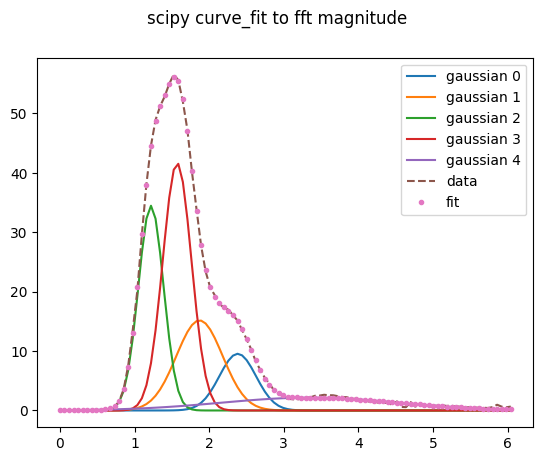

In [ ]:
for i in range(5):
    plt.plot(freq[len(freq)//2:len(freq)//2+100], 
             gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[i, i+5, i+10]]), label=f'gaussian {i}')
    
plt.plot(f, mag, '--', label='data')
plt.plot(f, gaussian_5(f, *popt), '.', label='fit')
plt.legend()
plt.suptitle('scipy curve_fit to fft magnitude')

In [ ]:
# i=0
# new_ = np.abs(fft_echo[len(freq)//2:len(freq)//2+100]) \
#                     - gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[0, 0*3+1, 0*3+2]]) \
#                     - gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[1, 1*3+1, 1*3+2]]) \
#                     - gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[2, 2*3+1, 2*3+2]]) \
#                     # - gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[3, 3*3+1, 3*3+2]]) \
#                     # - gaussian(freq[len(freq)//2:len(freq)//2+100], *popt[[4, 4*3+1, 4*3+2]])
# plt.plot(freq[len(freq)//2:len(freq)//2+100], new_)

In [186]:
from scipy.interpolate import interp1d
# finding the phase shifts
angles = np.unwrap(np.angle(fft_echo[len(freq)//2:len(freq)//2+100]))
interp = interp1d(f, angles)
means = popt[4:9]
shifts = interp(means)


In [187]:
freq

array([-249.975     , -249.91397095, -249.85294189, ...,  249.79191284,
        249.85294189,  249.91397095], shape=(8192,))

Text(0.5, 0.98, 'phase shifts at fitted peaks (unwrapped)')

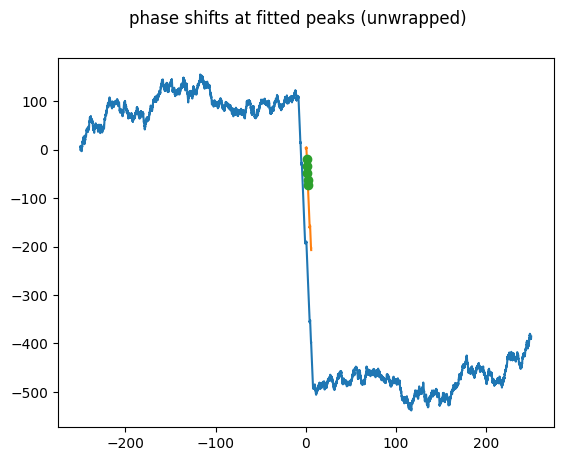

In [188]:
plt.plot(freq, np.unwrap(np.angle(fft_echo)))
plt.plot(f, angles)
plt.plot(means, shifts, 'o')
plt.suptitle('phase shifts at fitted peaks (unwrapped)')

### directly fit morlet

In [167]:
a_t

array([15.53584557, 19.54201869, 81.28712354, 86.325987  ,  0.72685185])

In [170]:
sigma_t

array([0.64919563, 0.51409466, 0.94103813, 0.8266341 , 0.13409017])

In [175]:
shifts

array([-62.84989636, -72.95895354, -48.66013831, -18.60465011,
       -34.29705039])

In [ ]:
t, a_t[i], mu_t[i], sigma_t[i], mu_f[i]

/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_8485/564630044.py:2: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(j * 2 * np.pi * f * (t-mu))
/var/folders/vg/g8h80y317zj5sfz8_f4l85wddxx210/T/ipykernel_8485/564630044.py:2: RuntimeWarning: invalid value encountered in multiply
  return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(j * 2 * np.pi * f * (t-mu))


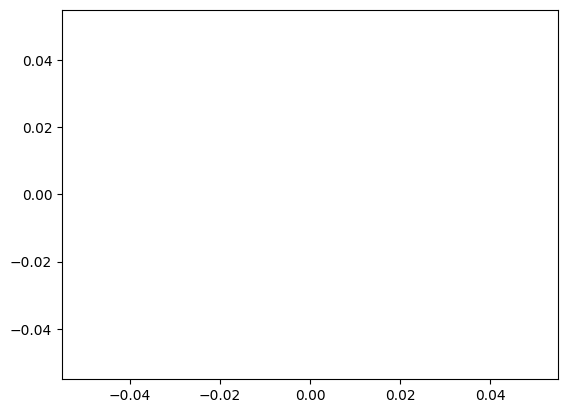

In [172]:
def morlet_function(t, a, mu, sigma, f):
    return a * np.exp(-(t - mu)**2 / (2 * sigma**2)) * np.exp(j * 2 * np.pi * f * (t-mu))

t = np.linspace(0, 10000)
a_f,mu_f,sigma_f = popt[:5],popt[5:10],popt[10:]

a_t = a_f/sigma_f/(2*np.pi)**0.5
mu_t = shifts/2/np.pi/mu_f/dset.dt
sigma_t = 1/2/np.pi/sigma_f/dset.dt

for i in range(len(a_t)):
    plt.plot(t, np.abs(morlet_function(t, a_t[i], mu_t[i], sigma_t[i], mu_f[i])) )

### try with inverse fft

### torch spectogram

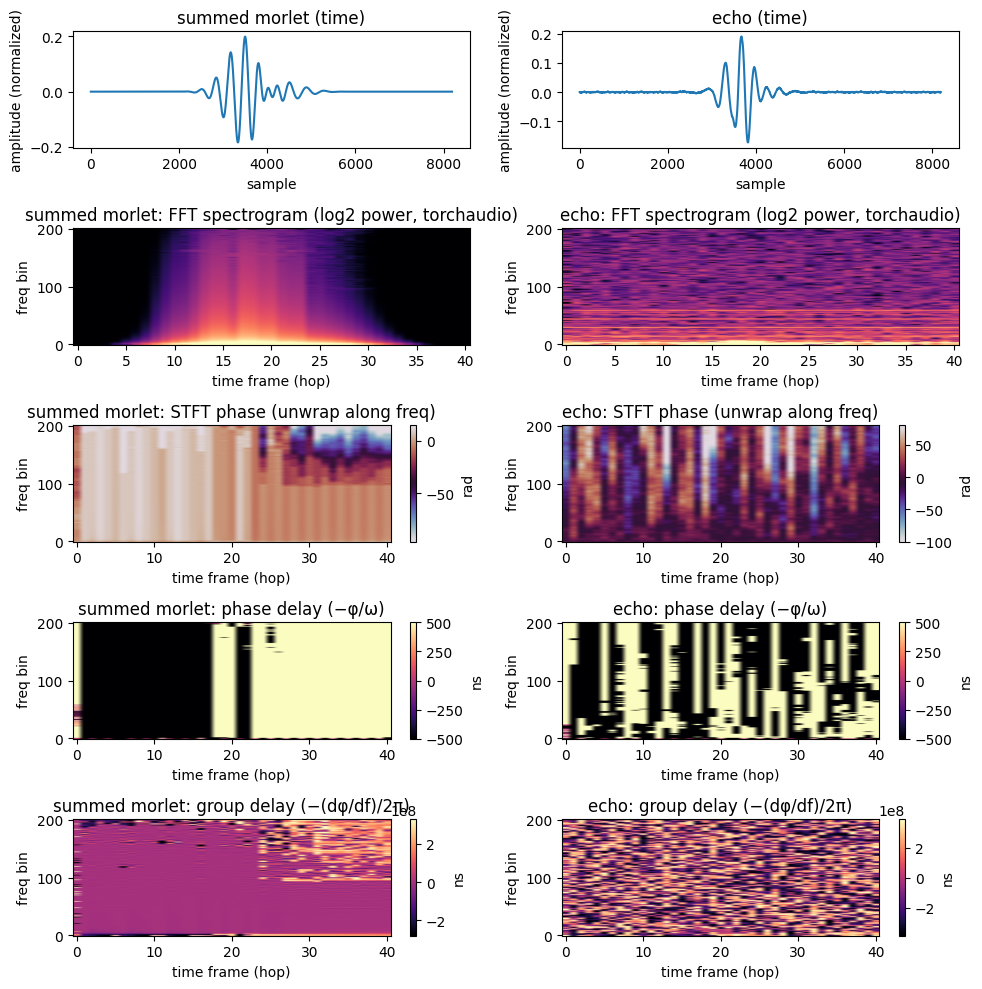

In [41]:
import torchaudio
import matplotlib.pyplot as plt
import torch
import numpy as np
from models.morlet_fitter import morlet_1D_fitters_real

i = 1034
data_crop = 2**13
fig, axs = plt.subplots(5, 2, figsize=(10, 10))

sample_rate = float(1.0 / dset.dt)
# Same window/hop as default torchaudio Spectrogram (n_fft=400, hop=win_length/2=200)
N_FFT, HOP = 400, 200
# Match torchaudio: power=2.0, same STFT; use for log2 mag image like the small torchaudio example
spec_pow = torchaudio.transforms.Spectrogram(
    n_fft=N_FFT, hop_length=HOP, power=2.0, center=True
)
win = torch.hann_window(N_FFT)
freqs = np.fft.rfftfreq(N_FFT, d=1.0 / sample_rate)
omega = 2.0 * np.pi * freqs
omega[0] = omega[1]  # avoid DC divide


def to_torch1d(wave_1d):
    return torch.as_tensor(wave_1d, dtype=torch.float32).reshape(-1)


def stft_complex(wave_1d):
    w = to_torch1d(wave_1d)
    S = torch.stft(
        w,
        n_fft=N_FFT,
        hop_length=HOP,
        win_length=N_FFT,
        window=win.to(w.device),
        center=True,
        return_complex=True,
    )
    return S.cpu().numpy()


def stft_ims(wave_1d):
    S = stft_complex(wave_1d)
    phase = np.unwrap(np.angle(S), axis=0)
    t_delay_ns = -phase / omega[:, None] * 1e9
    dphi_df = np.apply_along_axis(
        lambda p: np.gradient(p, freqs), 0, phase
    )  # slice along rows = phase vs freq; axis 1 would be time, wrong for len(freqs)
    g_delay_ns = -(dphi_df) / (2.0 * np.pi) * 1e9
    return phase, t_delay_ns, g_delay_ns


def imshow2d(X, ax, title, cbar_label=None, cmap="magma", robust=True, vmin=None, vmax=None):
    if vmin is None and vmax is None and robust:
        vmin, vmax = np.nanpercentile(X, 1), np.nanpercentile(X, 99)
    m = ax.imshow(X, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    if cbar_label is not None:
        plt.colorbar(m, ax=ax, label=cbar_label)


def spec_log2(ax, w_1d, title):
    w = to_torch1d(w_1d).unsqueeze(0)
    P = spec_pow(w).squeeze(0).numpy()
    imshow2d(np.log2(P + 1e-20), ax, title, cmap="magma")


def plot_column(wave, col, title_tag):
    y = np.asarray(wave, dtype=np.float32)
    phase, t_delay, g_delay = stft_ims(wave)
    axs[0, col].set_title(f"{title_tag} (time)")
    axs[0, col].plot(y)
    axs[0, col].set_xlabel("sample")
    axs[0, col].set_ylabel("amplitude (normalized)")

    spec_log2(
        axs[1, col], wave, f"{title_tag}: FFT spectrogram (log2 power, torchaudio)"
    )

    imshow2d(phase, axs[2, col], f"{title_tag}: STFT phase (unwrap along freq)", cmap="twilight", cbar_label="rad")
    imshow2d(
        t_delay,
        axs[3, col],
        f"{title_tag}: phase delay (−φ/ω)",
        cbar_label="ns",
        robust=False,
        vmin=-500,
        vmax=500,
    )  # match original 1D phase-delay row (ns)
    imshow2d(
        g_delay, axs[4, col], f"{title_tag}: group delay (−(dφ/df)/2π)", cbar_label="ns"
    )

    for r in (1, 2, 3, 4):
        axs[r, col].set_xlabel("time frame (hop)")
    axs[1, col].set_ylabel("freq bin")
    for r in (2, 3, 4):
        axs[r, col].set_ylabel("freq bin")


morlet_class = morlet_1D_fitters_real(
    limits=[1, dset.spec_len, dset.spec_len / 5, 0.05]
)
pars = torch.tensor(
    [
        [
            [0.2, 3500, 400, 3.0e-03],
            [0.025, 4500, 400, 2.5e-03],
            [0.1, 4000, 200, 3.5e-03],
        ],
    ]
)

test_ = morlet_class.generate_fit(pars, data_crop)
test_morlet_sum = test_.sum(axis=1)[0].numpy()
test_echo = dset.data["processed_voltage_echo_forward"][i][:data_crop]

plot_column(test_morlet_sum, 0, "summed morlet")
plot_column(test_echo, 1, "echo")
fig.tight_layout()


In [5]:
# ## SAVE CELL
# dat = pj.loadPickle('/Users/xz498/Desktop/ultrasound project/data analysis/example data/SA_tomography_foil_tape_scan.pickle')
# # dat['parameters']
# # omega_ = dat['parameters']['measureTime']*1e-6/dat['parameters']['samples']*2.25e6
# # omega_

# # for i in range(len(dat)-2):
# dat['parameters']


In [6]:
# dset.display_dict_tree()

## Interactive Viewer with Slider

Use the slider below to browse through all scans interactively.

In [7]:
# vals = abs(dset[:][1]).max(axis=1)
# plt.imshow(vals.reshape(dset.image_shape))
# plt.colorbar()

In [8]:
# Create interactive viewer with slider
from viz.visualize_scan_data import plotly_viewer
    
plotly_viewer(dset)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

...

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## try training model with morlet packet

goals:
- figure out mean position and f of morlet packet
- using this, calculate speed of sound in this water

In [20]:
from models.morlet_fitter import Fitter_AE, morlet_1D_fitters_real
from autophyslearn.spectroscopic.nn import block_factory, Conv_Block, FC_Block  # pyright: ignore[reportMissingImports]
from autophyslearn.spectroscopic.nn import Multiscale1DFitter
# from data.custom_sampler import Gaussian_Sampler
import torch

num_fits = 4 # number of curves to sum up
num_params = 4 # number of parameters to fit
# todo: change wandb naming to include noise level, group and regularization technique
# todo: test more num fits
model = Fitter_AE(function=morlet_1D_fitters_real,
                dset=dset,
                num_params=num_params,
                num_fits=num_fits,
                checkpoints_label='ultrasound_water',
                input_channels = 1,
                learning_rate=1e-4,
                device='cpu',
                encoder = Multiscale1DFitter,
                encoder_params = {
                    "model_block_dict": { # factory wrapper for blocks
                            "hidden_x1": block_factory(Conv_Block)(output_channels_list=[128,128], 
                                                                    kernel_size_list=[111,11], 
                                                                    pool_list=[1000,100], 
                                                                    max_pool=False),
                            "hidden_xfc": block_factory(FC_Block)(output_size_list=[128,64]), # remove 2nd block and skip connections
                            "hidden_x2": block_factory(Conv_Block)(output_channels_list=[32,16], 
                                                                    kernel_size_list=[5,3], 
                                                                    pool_list=[64,32], 
                                                                    max_pool=True),
                            "hidden_embedding": block_factory(FC_Block)(output_size_list=[8*num_fits,num_params*num_fits], last=True),
                        },
                        # TEST: LIMITS,
                        "skip_connections": {'hidden_xfc': 'hidden_embedding'},
                        # "skip_connections": {},
                        "function_kwargs": {'limits': [1, # amplitude
                                                       dset.spec_len, # mean
                                                       dset.spec_len/5, # stdev
                                                       0.05 # +-1% of the angular frequency scaled for step size
                                                        ]
                                                       
                                                    #    1e-2] # freq max (100 MHz)
                                            } 
                    },
                )


### Train model for several epochs


In [21]:
# import wandb
# wandb.init(group='sub_sampler_type', name='sub_noise_level') # later change config for regularization

model.train(epochs=5,save_every=10, batch_size=10, log_wandb=False, 
            # lr_scheduling=True,
            # coef1=1e-3
            )

/Users/xz498/Desktop/ultrasound project/data analysis/example data/ultrasound_water/checkpoints/voltage_echo_forward


100%|██████████| 192/192 [00:22<00:00,  8.72it/s]


Epoch: 000/005 | Train Loss: 0.0346
.............................


100%|██████████| 192/192 [00:25<00:00,  7.55it/s]


Epoch: 001/005 | Train Loss: 0.0047
.............................


...

Epoch: 002/005 | Train Loss: 0.0025
.............................


100%|██████████| 192/192 [00:22<00:00,  8.36it/s]


Epoch: 003/005 | Train Loss: 0.0021
.............................


100%|██████████| 192/192 [00:23<00:00,  8.31it/s]

Epoch: 004/005 | Train Loss: 0.0020
.............................


### Embeddings

In [22]:
def write_scaled_embedding(batch_size=1):
    model.dataloader.batch_size
    fits = np.zeros((dset.shape[0],model.num_fits,dset.shape[-1]))
    params = np.zeros((dset.shape[0],model.num_fits,4))
    for i, (idx, x) in enumerate(tqdm(model.dataloader, leave=True, total=len(model.dataloader))):
        with torch.no_grad():
            f, p = model.encoder(x.float().to(model.device))
            fits[idx] = f.cpu().numpy()
            params[idx] = p.cpu().numpy()
            # params[idx] = np.append(p.cpu().numpy(), np.full((len(idx),num_fits,1), 4500.0), axis=-1,)
    return fits, params


fits, params = write_scaled_embedding(batch_size=1)

# sweep frequencies and search for resonances 
# attenuation in each layer accounts for spherical nature of wave
# data for one to 20 layers
# measure waveform from 30-50, measuring thermal gradient. shoul dbe the same as 40 (mean), so why isnt it?
# goal: use ultrasound to monitor the thermal expansion so we can decreasing charging rate. this way the battery is less likely to experience stress and can cycle more

100%|██████████| 192/192 [00:09<00:00, 20.26it/s]


In [23]:
from viz.visualize_scan_data import training_viewer
x,z = 6,25
training_viewer(dset, fits, params, idx=x*dset.image_shape[1]+z)
    